In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
from PIL import Image, ImageEnhance
from tqdm import tqdm
import datetime
import cv2

import torch

DATA_PATH = "E:/ML/UBC"
print(DATA_PATH)


E:/ML/UBC


In [2]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Dataset

In [4]:
testList = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))
testList.head()

,image_id,image_width,image_height
0,41,28469,16987


In [ ]:
from sklearn.preprocessing import LabelEncoder

import pickle 
with open('LabelEncoder.pkl', 'rb') as f:
    enc = pickle.load(f) 
print(enc.classes_)
enc.transform(["LGSC"])

In [5]:

IMG_SIZE = (256, 256)
eps=1e-12

def readImage(path, skipResize=False):
    data = Image.open(path)
        
    w, h = data.width, data.height
    # centerWindow = data[w//4:3*w//4, h//4:3*h//4]
    # medValue = np.median(data)

    #Center crop
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w]

    # data = data - np.min(data)
    # data = data * 1.0/(np.max(data)+eps)

    w, h = data.width, data.height

    # resize
    if not skipResize:
        if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
            data = np.array(data.resize(IMG_SIZE))

    return data


In [40]:
NRows = 3
NCols = 3
PatchSize=512

allIds = testList["image_id"].unique()

def getPatches(data):
    patches=[]
    if data.shape[0]<NRows*PatchSize or data.shape[1]<NCols*PatchSize:
        PatchSizeAdj = 256
    else:
        PatchSizeAdj = PatchSize
    wDiff = data.shape[1] - NCols*PatchSizeAdj
    wDist = wDiff/(NCols+1)
    hDiff = data.shape[0] - NRows*PatchSizeAdj
    hDist = hDiff/(NRows+1)
    for j in range(NRows):
        yPos = int(hDist+(PatchSizeAdj+hDist)*j)
        for i in range(NCols):
            xPos = int(wDist+(PatchSizeAdj+wDist)*i)
            patch = data[yPos:yPos+PatchSizeAdj, xPos:xPos+PatchSizeAdj]
            hist , _ = np.histogram(patch, bins=10, range=(0.0,255.0))
            # If most pixels are very bright or dark the patch is outside the relevant area
            if ((hist[0] + hist[-1])/(np.sum(hist)+eps)) > 0.98:
                continue
            patches.append(patch)
    return np.array(patches).astype(np.float32)/255.0


def getData(id):
    imFile =  os.path.join(DATA_PATH, "test_images", str(id)+".png")
    data = cv2.imread(imFile)
    patches = getPatches(data)
    del data
    return patches, id


def generator():
    for trainId in allIds:
        yield getData(trainId)


In [41]:
g = generator()
testInstance = next(g)

id  41
max  1.0
len  9
shape  (9, 512, 512, 3)


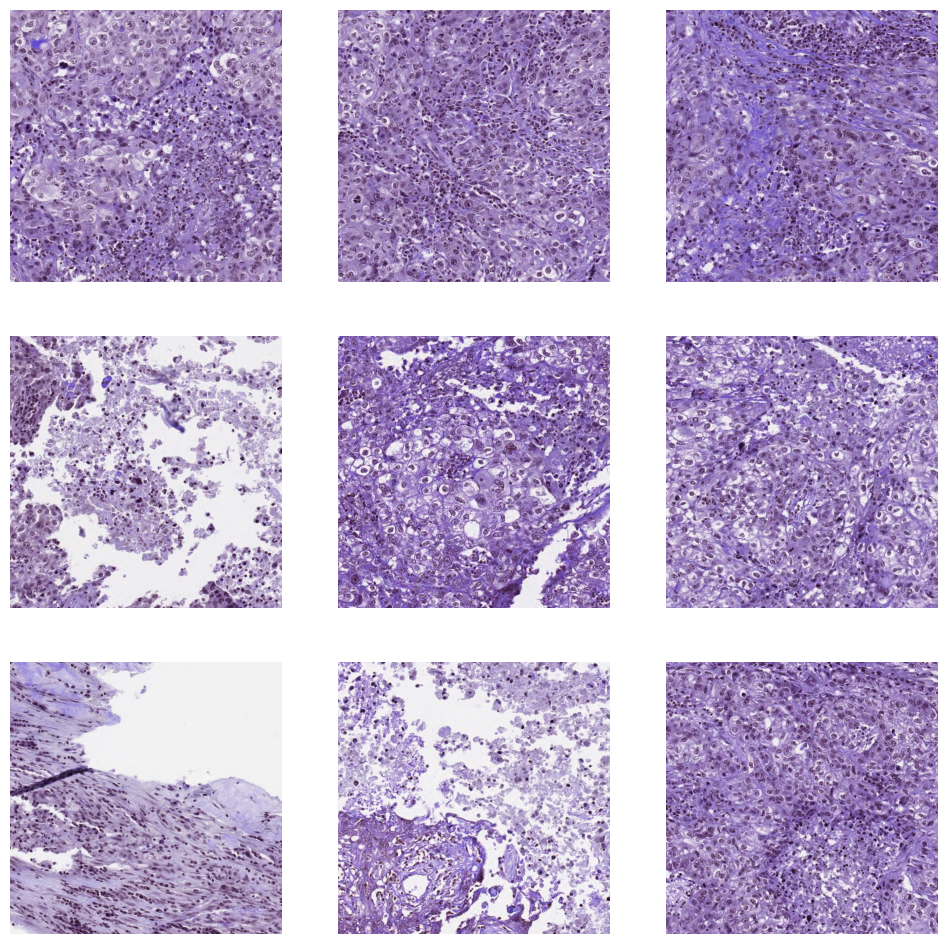

In [39]:
# plt.imshow(testInstance[0][0,:,:,:])
print("id ", testInstance[1])
print("max ", np.max(testInstance[0]))
print("len ", len(testInstance[0]))
print("shape ", testInstance[0].shape)


plt.figure(figsize=(12,12))
for i in range(len(testInstance[0])):
    plt.subplot(3,3,i+1)
    plt.imshow(testInstance[0][i,:,:,:])
    _= plt.axis("off")


In [ ]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(allIds))

dataLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
for X, ids in dataLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {X.shape} {X.dtype}")
    print(f"Shape of target Bowel: {ids.dtype}")
    # print(targets)
    break

In [ ]:
idx=1
print(ids[idx])
# plt.figure(figsize=(12,12))
plt.imshow(X[idx,:,:,:])
_=plt.axis("off")

## Pytorch Model

In [ ]:
from torch import nn
import torchinfo
from torch import nn
import torch
from modelZoo.models import Res2DModel

model = torch.jit.load('model.pt')

print(model)

In [ ]:
result=[]
def test(dataloader, model, epoch):
    print("Start Validation...")
    model.eval()
    loss = 0
    for batch, (X, id) in enumerate(g):
        X = torch.Tensor(X)
        X = X.movedim(-1,1)
        X, y = X.to(device), y.to(device)
        pred = model(X)
        targetLabel = torch.argmax(y, dim=1)
        vals, counts = np.unique(targetLabel.detach().cpu().numpy(), return_counts=True)
        maxIdx= np.argmax(counts)
        maxVal = vals[maxIdx]
        result.append([id, maxVal])


test(dataLoader, model)
